In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

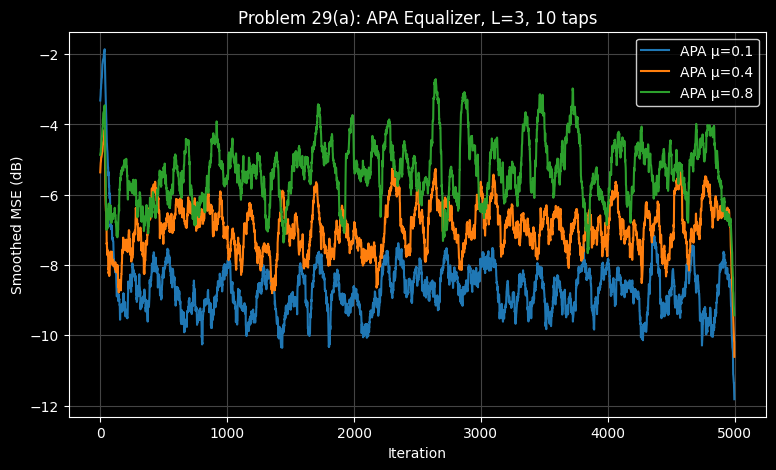

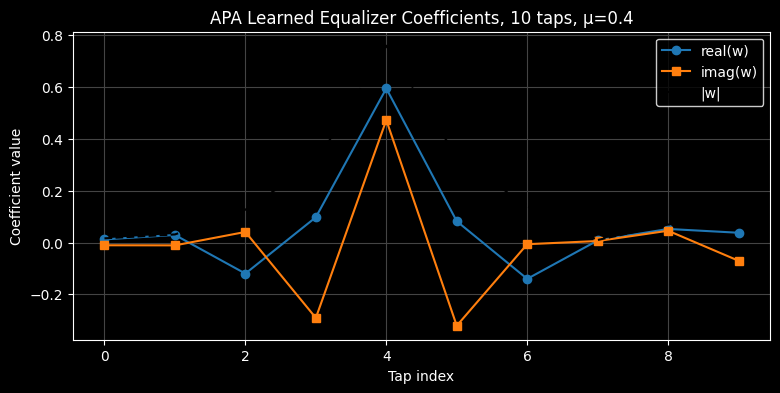

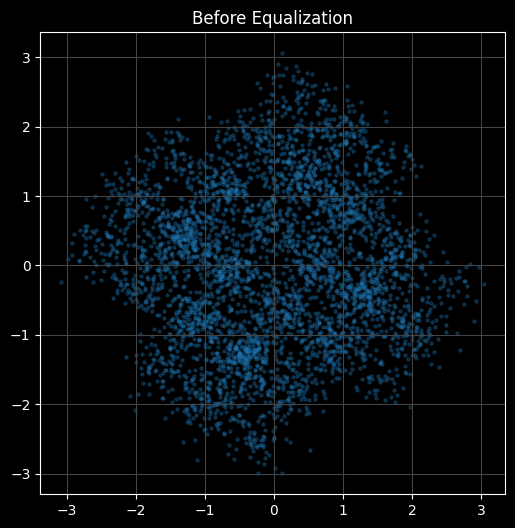

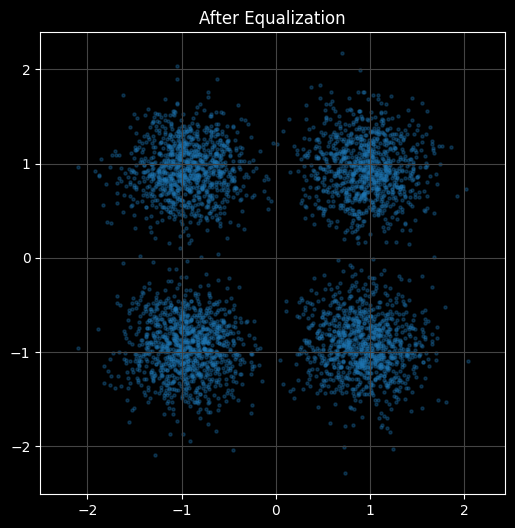

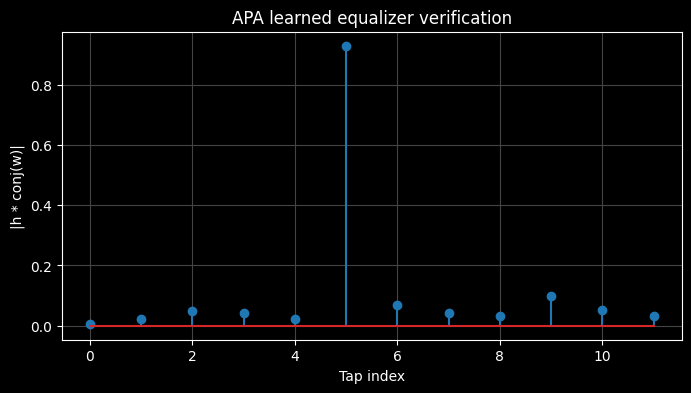

Peak tap: 5
Peak value: (0.92887604+0.010152146j)


In [3]:
def eqQamProb2930(algo="apa", mu=0.4, n_taps=10):
  delay = n_taps // 2

  # 4-QAM transmitted symbols: ±1 ± j
  s = (
    np.random.choice([-1, 1], size=N + delay + n_taps + len(h))
    + 1j * np.random.choice([-1, 1], size=N + delay + n_taps + len(h))
  ).astype(np.complex64)

  # Channel output without noise
  x_tilde = np.convolve(s, h, mode="full")[:N].astype(np.complex64)

  # Add complex AWGN, SNR = E{|x_tilde|^2}/sigma_n^2 = 20
  sig_pow = np.mean(np.abs(x_tilde) ** 2)
  noise_pow = sig_pow / snr_linear

  noise = np.sqrt(noise_pow / 2.0) * (
    np.random.randn(N) + 1j * np.random.randn(N)
  ).astype(np.complex64)

  r = (x_tilde + noise).astype(np.complex64)

  # Correct desired signal:
  # y[k] should estimate s[k-delay]
  d = adspfilter.eqfirDesired(s, N, delay)

  if algo == "apa":
    # Problem says L = 3.
    # Your class uses P+1 vectors, so pass P = L-1 = 2.
    eq = adspfilter.AffineProjection(
      filter_order=n_taps - 1,
      mu=mu,
      P=2,
      delta=1e-3,
    )
  elif algo == "nlms":
    eq = adspfilter.NLMS(
      filter_order=n_taps - 1,
      mu=mu,
      tau=1e-3,
    )
  else:
    raise ValueError("algo must be 'apa' or 'nlms'")

  y, e, w_hist = eq(r, d, train=True)

  rx, d_aligned, y, e, start_idx = adspfilter.eqResultAlign(r, d, y, e)

  mse = np.abs(e) ** 2
  mse_smooth = np.convolve(mse, np.ones(64) / 64.0, mode="same")

  return rx, d_aligned, y, e, mse_smooth, eq.w, w_hist, start_idx
  
def plotLearnedCoeff(w, title):
  n = np.arange(len(w))

  plt.figure(figsize=(9, 4))
  plt.plot(n, w.real, "o-", label="real(w)")
  plt.plot(n, w.imag, "s-", label="imag(w)")
  plt.plot(n, np.abs(w), "k--", label="|w|")
  plt.xlabel("Tap index")
  plt.ylabel("Coefficient value")
  plt.title(title)
  plt.grid(True)
  plt.legend()
  plt.show()

def plotEqVerify(w, h, title="Combined channel + equalizer"):
  # Your equalizer computes y = w^H x,
  # so the physical equalizer impulse response is conj(w).
  heq = np.convolve(h, np.conj(w))

  plt.figure(figsize=(8, 4))
  plt.stem(np.arange(len(heq)), np.abs(heq))
  plt.xlabel("Tap index")
  plt.ylabel("|h * conj(w)|")
  plt.title(title)
  plt.grid(True)
  plt.show()

  print("Peak tap:", np.argmax(np.abs(heq)))
  print("Peak value:", heq[np.argmax(np.abs(heq))])
  
np.random.seed(10)

# ============================================================
# Problem setup
# ============================================================
N = 5000
snr_linear = 20.0
mus = [0.1, 0.4, 0.8]

h = np.array([
  0.34 - 0.27j,
  0.87 + 0.43j,
  0.34 - 0.21j,
], dtype=np.complex64)
apa_results = {}

plt.figure(figsize=(9, 5))

for mu in mus:
  rx, d, y, e, mse, w, w_hist, start_idx = eqQamProb2930(algo="apa", mu=mu, n_taps=10)

  apa_results[mu] = (rx, d, y, e, mse, w, w_hist, start_idx)

  x_axis = start_idx + np.arange(len(mse))
  plt.plot(10 * np.log10(mse + 1e-12), label=f"APA μ={mu}")

plt.xlabel("Iteration")
plt.ylabel("Smoothed MSE (dB)")
plt.title("Problem 29(a): APA Equalizer, L=3, 10 taps")
plt.grid(True)
plt.legend()
plt.show()

rx, d, y, e, mse, w, w_hist, start_idx = apa_results[0.4]
w_apa = apa_results[0.4][5]
plotLearnedCoeff(w_apa, "APA Learned Equalizer Coefficients, 10 taps, μ=0.4")

warmup = 1000

plt.figure(figsize=(6, 6))
plt.scatter(rx[warmup:].real, rx[warmup:].imag, s=5, alpha=0.3)
plt.title("Before Equalization")
plt.grid(True)
plt.axis("equal")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y[warmup:].real, y[warmup:].imag, s=5, alpha=0.3)
plt.title("After Equalization")
plt.grid(True)
plt.axis("equal")
plt.show()

plotEqVerify(w, h, "APA learned equalizer verification")

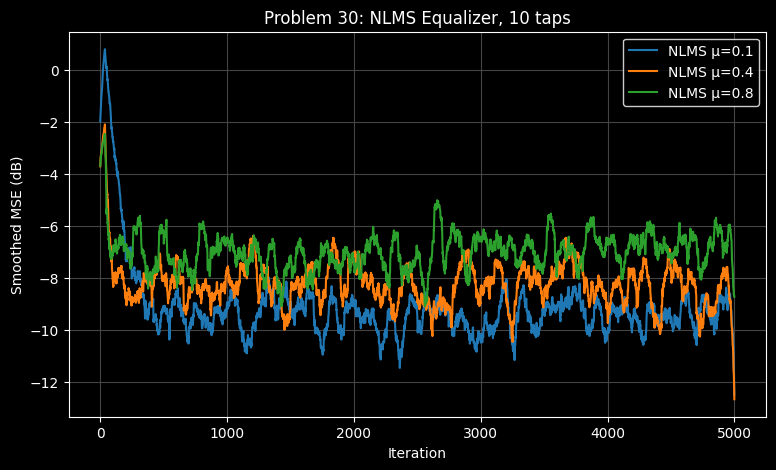

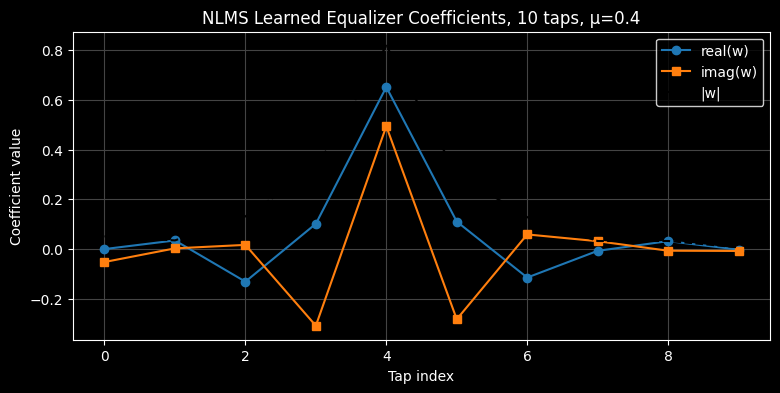

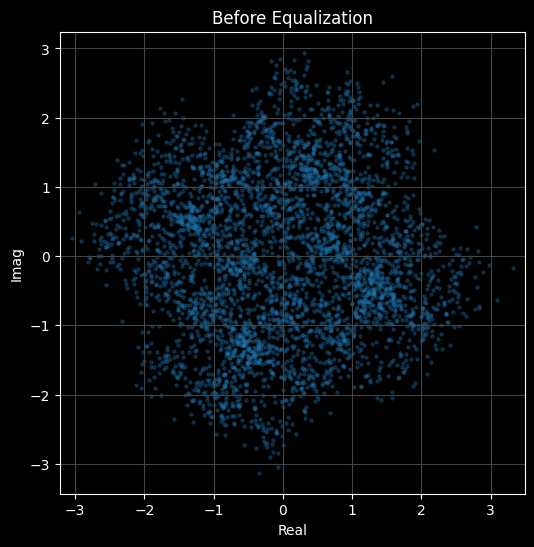

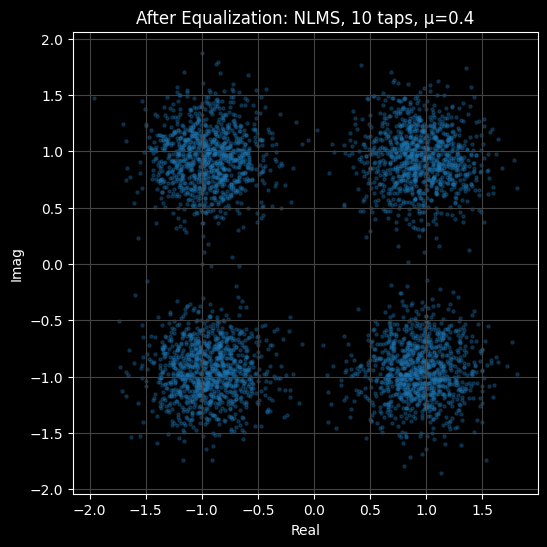

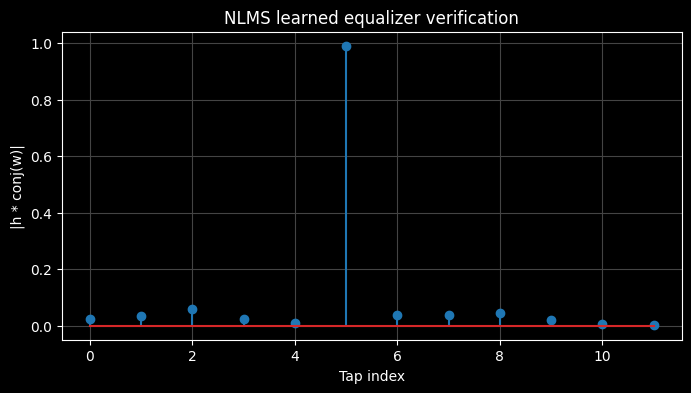

Peak tap: 5
Peak value: (0.9909905-0.000663504j)


In [4]:
# ----------------------------
# Problem 30: NLMS, n_taps = 10
# ----------------------------
nlms_results = {}

plt.figure(figsize=(9, 5))

for mu in mus:
  rx, d, y, e, mse, w, w_hist, start_idx = eqQamProb2930(
    algo="nlms",
    mu=mu,
    n_taps=10,
  )

  nlms_results[mu] = (rx, d, y, e, mse, w, w_hist, start_idx)

  x_axis = start_idx + np.arange(len(mse))
  plt.plot(
    x_axis,
    10 * np.log10(mse + 1e-12),
    label=f"NLMS μ={mu}",
  )

plt.xlabel("Iteration")
plt.ylabel("Smoothed MSE (dB)")
plt.title("Problem 30: NLMS Equalizer, 10 taps")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Problem 30: NLMS constellation and learned coeffs
# ----------------------------
rx, d, y, e, mse, w, w_hist, start_idx = nlms_results[0.4]
w_nlms = nlms_results[0.4][5]
plotLearnedCoeff(w_nlms, "NLMS Learned Equalizer Coefficients, 10 taps, μ=0.4")
warmup = 1000

plt.figure(figsize=(6, 6))
plt.scatter(
  rx[warmup:].real,
  rx[warmup:].imag,
  s=5,
  alpha=0.3,
)
plt.title("Before Equalization")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.grid(True)
plt.axis("equal")
plt.show()


plt.figure(figsize=(6, 6))
plt.scatter(
  y[warmup:].real,
  y[warmup:].imag,
  s=5,
  alpha=0.3,
)
plt.title("After Equalization: NLMS, 10 taps, μ=0.4")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.grid(True)
plt.axis("equal")
plt.show()


plotEqVerify(w, h, "NLMS learned equalizer verification")

In [5]:
def makeEqW0(h, n_taps, delay):
  """
  Build a reference equalizer w0 for comparison.

  We solve for physical FIR equalizer q0 such that:
      h * q0 ≈ delayed impulse

  Since your adaptive filters store coefficients w such that:
      y = vdot(w, reg) = conj(w)^T reg

  the physical FIR taps are:
      q = conj(w)

  Therefore:
      w0 = conj(q0)
  """
  h = np.asarray(h, dtype=np.complex64)

  Lh = len(h)
  M = n_taps

  # Convolution matrix A so that:
  #   A @ q0 = h * q0
  A = np.zeros((Lh + M - 1, M), dtype=np.complex64)
  for i in range(M):
    A[i:i + Lh, i] = h

  # Desired delayed impulse
  desired = np.zeros(Lh + M - 1, dtype=np.complex64)
  desired[delay] = 1.0 + 0j

  # Least-squares solution for physical equalizer q0
  q0, _, _, _ = np.linalg.lstsq(A, desired, rcond=None)

  # Convert to your adaptive-filter stored coefficient convention
  w0 = np.conj(q0)

  return w0, q0, desired, A

def plotCoeffAgainstW0(w, w0, title):
  n = np.arange(len(w))

  plt.figure(figsize=(10, 4))
  plt.plot(n, w.real, "o-", label="learned real(w)")
  plt.plot(n, w.imag, "s-", label="learned imag(w)")
  plt.plot(n, w0.real, "o--", label="w0 real")
  plt.plot(n, w0.imag, "s--", label="w0 imag")
  plt.xlabel("Tap index")
  plt.ylabel("Coefficient value")
  plt.title(title)
  plt.grid(True)
  plt.legend()
  plt.show()

def plotCoeffMagAgainstW0(w, w0, title):
  n = np.arange(len(w))

  plt.figure(figsize=(9, 4))
  plt.plot(n, np.abs(w), "o-", label="|learned w|")
  plt.plot(n, np.abs(w0), "s--", label="|w0|")
  plt.xlabel("Tap index")
  plt.ylabel("Magnitude")
  plt.title(title)
  plt.grid(True)
  plt.legend()
  plt.show()

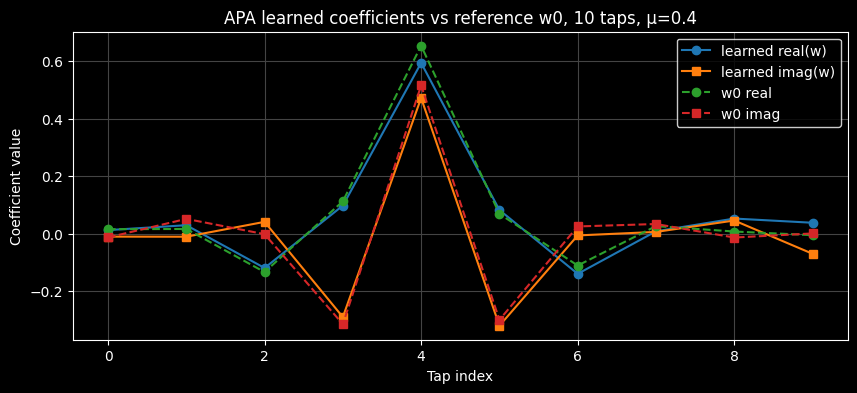

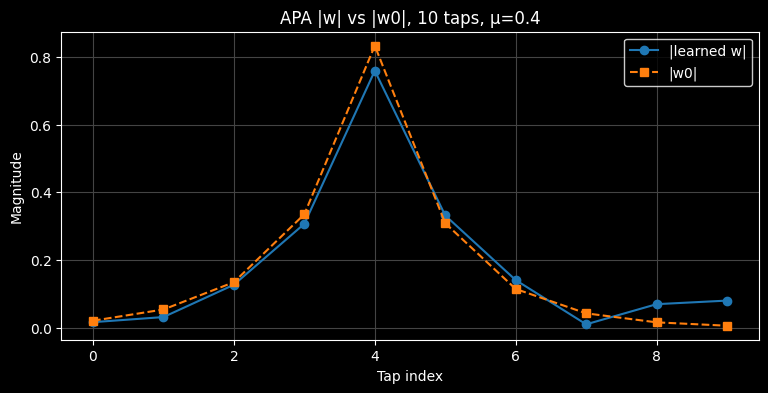

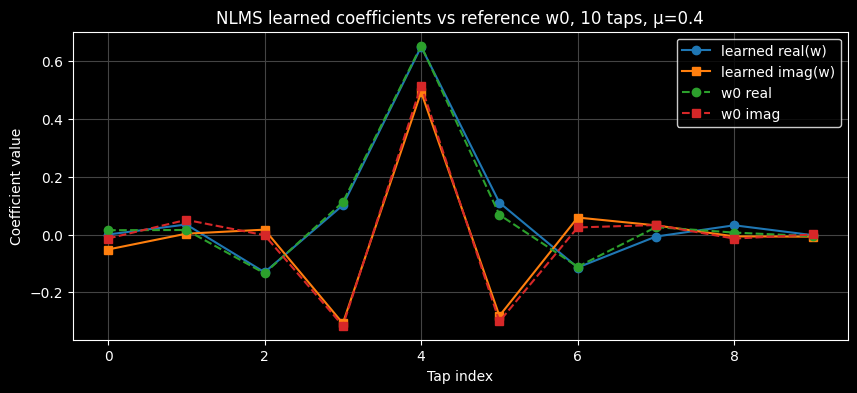

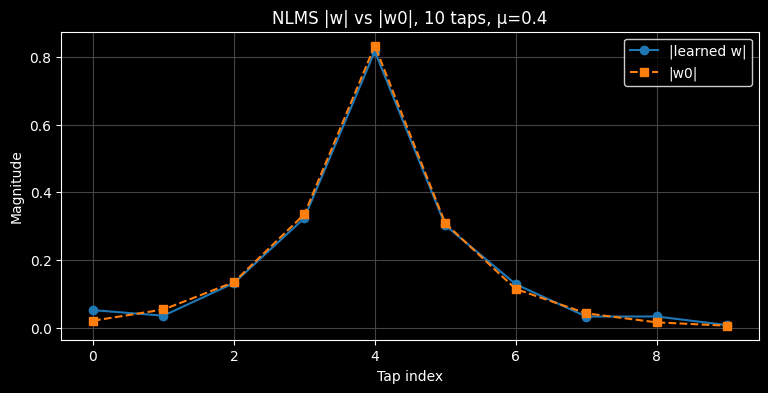

In [6]:
# Reference w0 for 10-tap equalizer
n_taps = 10
delay = n_taps // 2
w0_10, q0_10, desired_10, A_10 = makeEqW0(h, n_taps, delay)

# APA learned w
w_apa = apa_results[0.4][5]

# NLMS learned w
w_nlms = nlms_results[0.4][5]

plotCoeffAgainstW0(
  w_apa,
  w0_10,
  "APA learned coefficients vs reference w0, 10 taps, μ=0.4"
)

plotCoeffMagAgainstW0(
  w_apa,
  w0_10,
  "APA |w| vs |w0|, 10 taps, μ=0.4"
)

plotCoeffAgainstW0(
  w_nlms,
  w0_10,
  "NLMS learned coefficients vs reference w0, 10 taps, μ=0.4"
)

plotCoeffMagAgainstW0(
  w_nlms,
  w0_10,
  "NLMS |w| vs |w0|, 10 taps, μ=0.4"
)